## 相似性搜索
进行RAG时需要将查询向量与数据库中的海量向量进行相似性搜索，逐个计算不现实，所以需要一种高效的算法。主要思路有：
> 1）减少向量大小——通过降维或减少表示向量值的长度；

> 2）缩小搜索范围——通过聚类或将向量组织成树形、图形等进行过滤

#### K-Means
- 即先对数据进行K均值聚类，检索时只检索类中心的数据点，进而缩小搜索范围

- 但现实情况中，数据点不会天然有明显的聚类，往往区域的边界是相邻的。而在搜索的时候，如果搜索的内容正好处于两个分类区域的中间，就很有可能遗漏掉最相似的向量。最简单的就是每次多搜几个类中心，然后在这些质心对应的数据中再做搜索。

## Faiss
- 一个工业级的高维向量检索算法工具箱，将多种经典的、前沿的 ANN（近似最近邻）算法进行了高度优化的工程实现，并封装在统一的接口下。

### Product Quantization (PQ)
存储向量数据时，内存占用巨大。可以使用量化方法：在内存中可以将聚类中心里面每一个向量都用聚类中心的向量来表示，并维护一个所有向量到聚类中心的码本。

但对于高维数据，数据点之间的距离会呈指数级增长，这也就意味着，在高维坐标系中，需要更多的聚类中心点将数据点分成更小的簇，才能提高分类的质量。否则，向量和自己的聚类中心距离很远，会极大的降低搜索的速度和质量。一个 128 维的向量，需要维护 2^64 个聚类中心才能维持不错的量化结果

解决这个问题的方法是将向量分解为多个子向量，然后对每个子向量独立进行量化，比如将 128 维的向量分为 8 个 16 维的向量，然后在 8 个 16 维的子向量上分别进行聚类，因为 16 维的子向量大概只需要 256 个聚类中心就能得到还不错的量化结果，所以就可以将码本的大小从 2^64 降低到 8 * 256 = 2048 个聚类中心，从而降低内存开销。

使用的时候，只需要将这 8 个编码值，然后分别在 8 个子码本中搜索出对应的 16 维的向量，就能将它们直接拼接组合成一个 128 维的向量，从而得到最终的搜索结果。这也就是乘积量化（Product Quantization）的原理。

### Hierarchical Navigable Small Worlds (HNSW)
通过构建树或者构建图的方式来实现近似最近邻搜索。这种方法的基本思想是每次将向量加到数据库中的时候，就先找到与它最相邻的向量，然后将它们连接起来，这样就构成了一个图。当需要搜索的时候，就可以从图中的某个节点开始，不断的进行最相邻搜索和最短路径计算，直到找到最相似的向量。

这种算法能保证搜索的质量，但是如果图中所有的节点都以最短的路径相连，那么在搜索的时候，就同样需要遍历所有的节点。

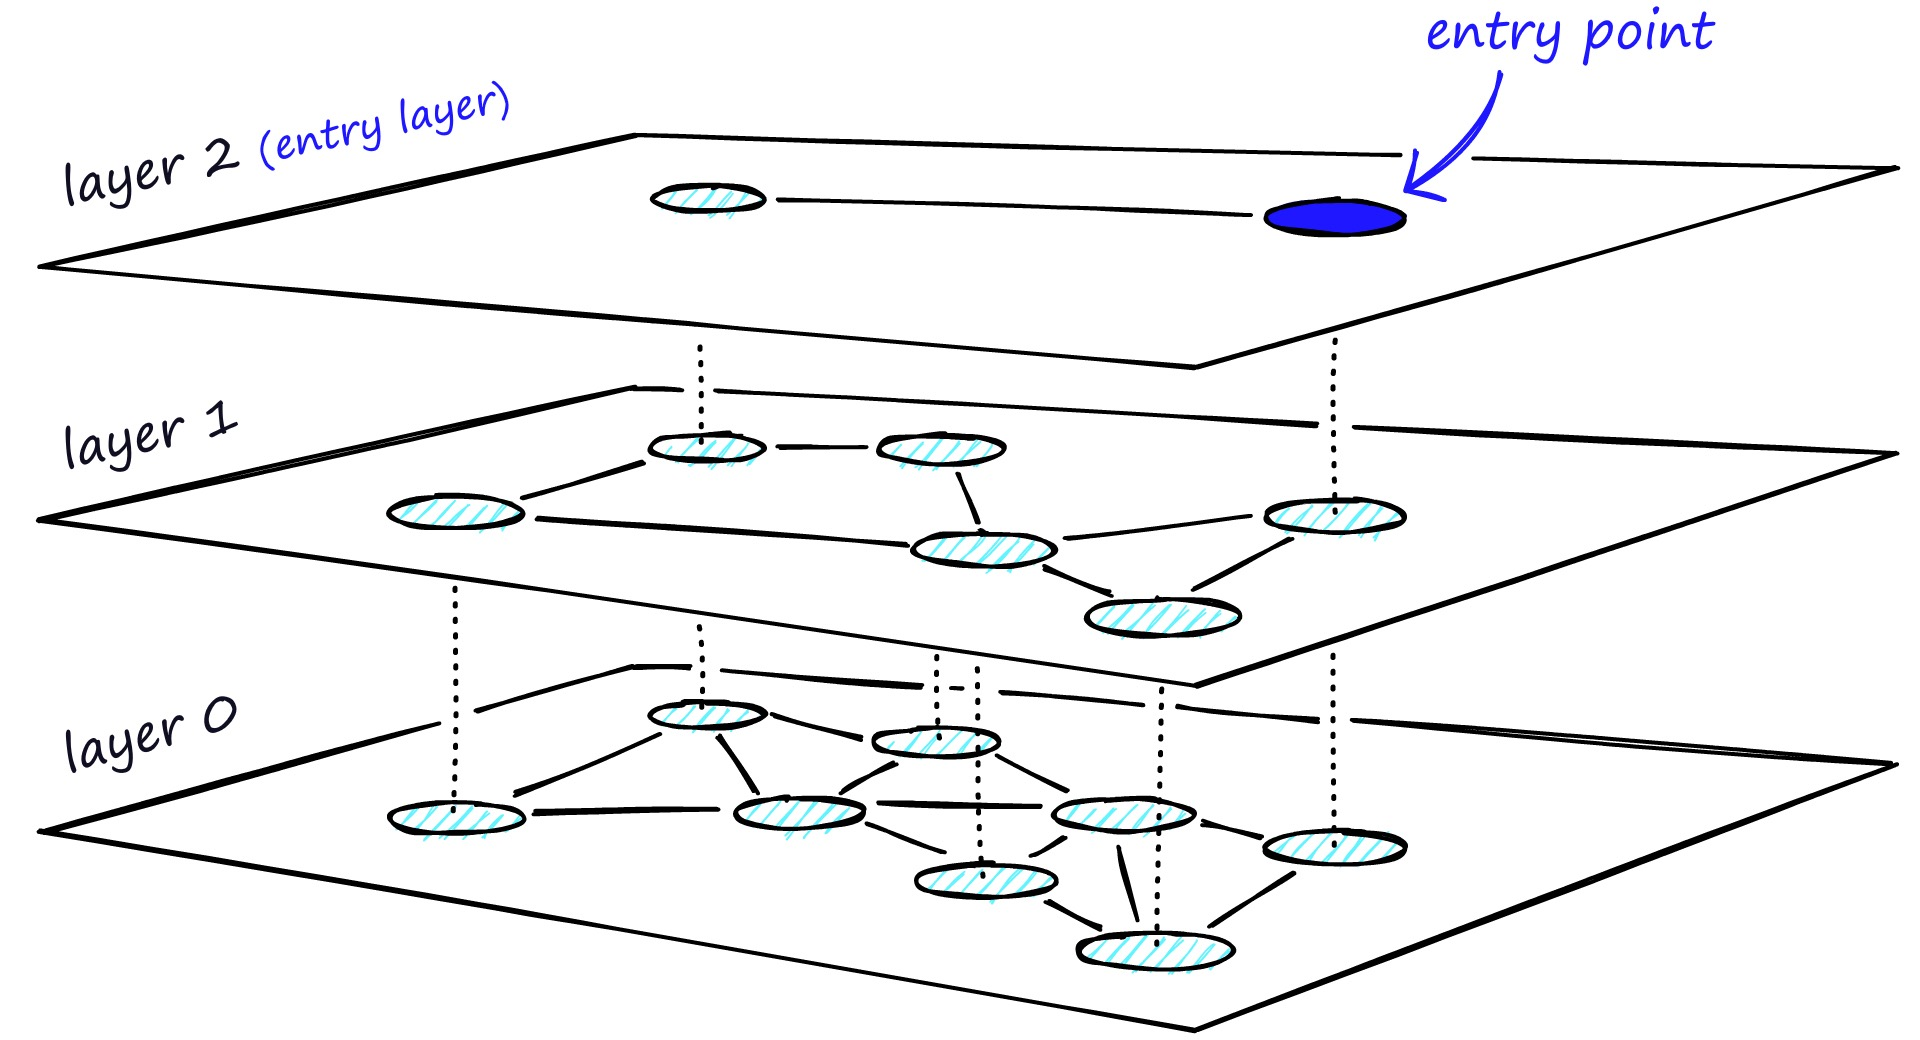

构建操作：每个数据随机定层数，越往上存的节点越少

查询：类似跳表算法，先在上层确定大致范围，不断往下搜。有点类似二分查找，但是高维的。

HNSW 算法是一种经典的空间换时间的算法，它的搜索质量和搜索速度都比较高，但是它的内存开销也比较大，因为不仅需要将所有的向量都存储在内存中。还需要维护一个图的结构，也同样需要存储。所以这类算法需要根据实际的场景来选择。

## Locality Sensitive Hashing (LSH)
LSH 使用一组哈希函数将相似向量映射到“桶”中，从而使相似向量具有相同的哈希值。这样，就可以通过比较哈希值来判断向量之间的相似度。

所以可以专门设计一种哈希函数，使得哈希碰撞的概率尽可能高，并且位置越近或者越相似的向量越容易碰撞，这样相似的向量就会被映射到同一个桶中。

#### 哈希函数设计
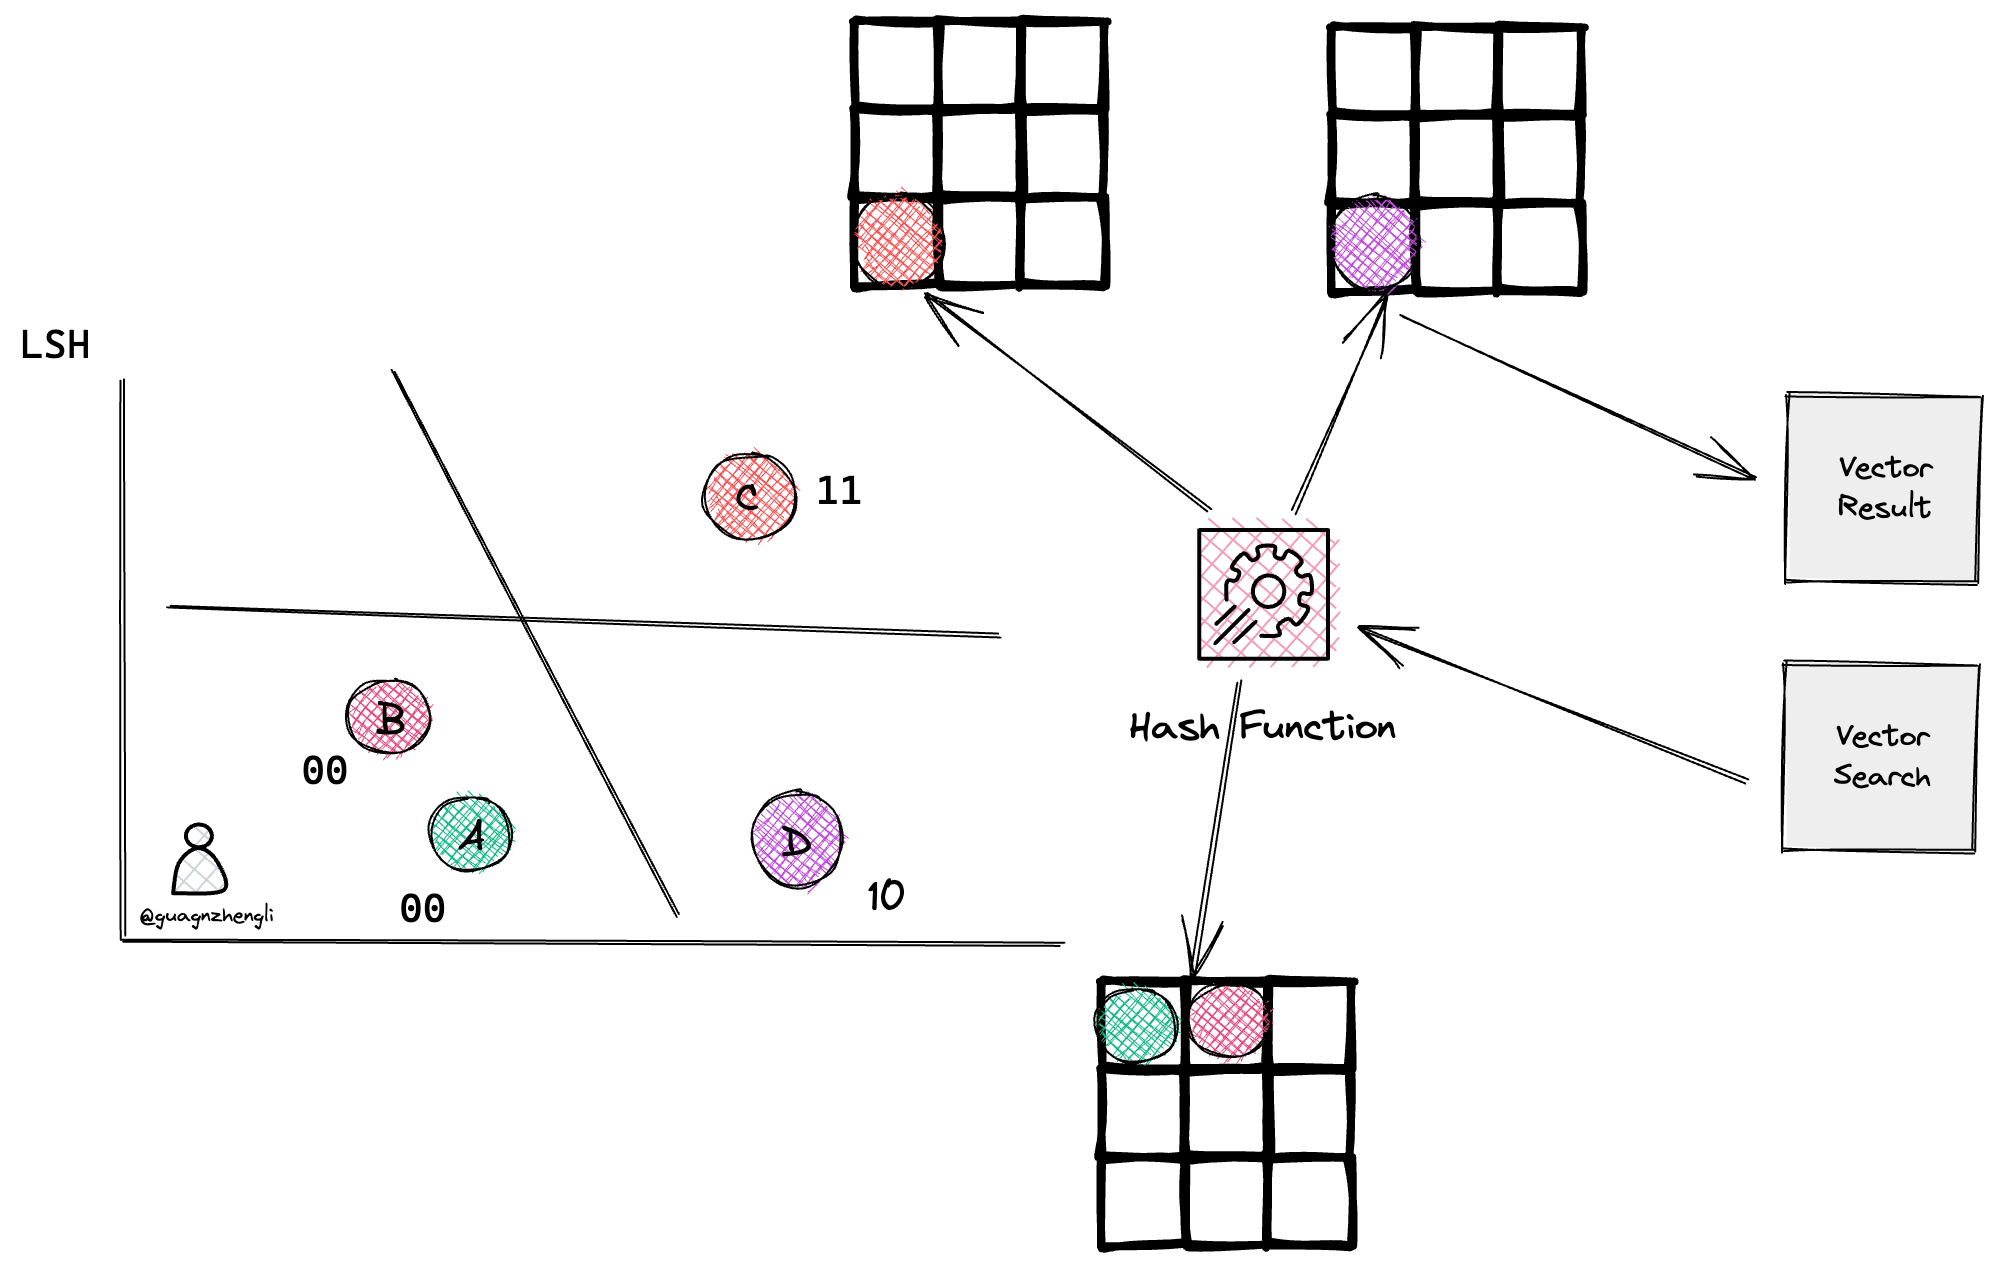

通过随机生成一个超平面，将多维坐标系划分为两个区域，从而区分相似性。参考二维坐标，划分后的编码010...作为哈希值。

但是在高维空间中，数据点之间的距离往往非常稀疏，数据点之间的距离会随着维度的增加呈指数级增长。导致计算出来的桶非常多，最极端的情况是每个桶中就一个向量，并且计算速度非常慢。所以实际上在实现 LSH 算法的时候，会考虑使用随机投影的方式，将高维空间的数据点投影到低维空间，从而减少计算的时间和提高查询的质量。


随机投影背后的基本思想是使用随机投影矩阵将高维向量投影到低维空间中。创建一个由随机数构成的矩阵，其大小将是所需的目标低维值。然后，计算输入向量和矩阵之间的点积，得到一个被投影的矩阵，它比原始向量具有更少的维度但仍保留了它们之间的相似性。

当我们查询时，使用相同的投影矩阵将查询向量投影到低维空间。然后，将投影的查询向量与数据库中的投影向量进行比较，以找到最近邻居。由于数据的维数降低了，搜索过程比在整个高维空间中搜索要快得多。